In [2]:
# importing packages
import torch
import matplotlib.pyplot as plt 
from torch import nn

### Pytorch Tensors

In [3]:
# creating a 3-dim tensor 
images = torch.rand((4, 28, 28))

In [3]:
# size of the tensor
images.shape

torch.Size([4, 28, 28])

In [4]:
# subsetting tensor 
second_image = images[1]

In [5]:
# shape of the subsetted tensor
second_image.shape

torch.Size([28, 28])

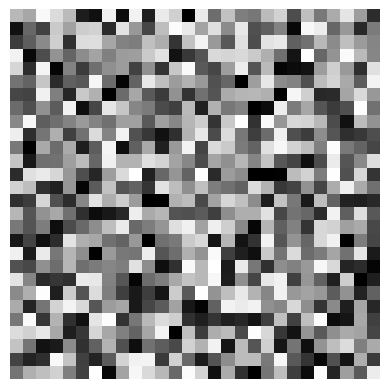

In [6]:
# potting the random tensor 
plt.imshow(second_image, cmap = "gray")
plt.axis("off") 
plt.show()

### PyTorch Neural Network

In [7]:
# creating Multi Layer Perceptron using the pytorch
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.hidden_layer = nn.Linear(input_size, 64)
        self.output_layer = nn.Linear(64, 2)
        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.activation(self.hidden_layer(x))
        return self.output_layer(x)

In [9]:
# initialising the object of the MLP class
model = MLP(input_size = 128)
print(model)

MLP(
  (hidden_layer): Linear(in_features=128, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=2, bias=True)
  (activation): ReLU()
)


In [10]:
# forward propagation with random numbers
x = torch.rand(128)
model.forward(x)

tensor([ 0.1457, -0.0115], grad_fn=<ViewBackward0>)

### Pytorch Loss Function 

In [33]:
# initialising CrossEntropyLoss object to compute the loss
loss = nn.CrossEntropyLoss() # used for classification problems 

In [24]:
# index of the label
target_tensor = torch.tensor([1])

In [25]:
# predicted score
predicted_tensor1 = torch.tensor([[2.0, 5.0]])

In [26]:
# computing the loss 
loss_value = loss(predicted_tensor1, target_tensor)

In [27]:
# loss value
loss_value

tensor(0.0486)

In [28]:
# predicted score
predicted_tensor2 = torch.tensor([[1.5, 1.1]])

In [31]:
# computing the loss
loss_value = loss(predicted_tensor2, target_tensor)

In [32]:
# loss value
loss_value

tensor(0.9130)

In [36]:
# creating MSELoss object to compute regression tasks 
loss_function = nn.MSELoss()

In [37]:
# true label and prediction to compute the loss
predicted_tensor = torch.tensor([320000.0])
actual_tensor = torch.tensor([300000.0])

In [38]:
# culculating the loss
loss_value = loss_function(predicted_tensor, actual_tensor)

In [39]:
loss_value.item()

400000000.0

### PyTorch Optimizers

In [40]:
# Pytorch optim module for train neural network |
import torch.optim as optim

In [41]:
optimizer = optim.SGD(model.parameters(), lr = 0.01, momentum = 0.9)

In [42]:
optimizer = optim.Adam(model.parameters(), lr = 0.01)

### Pytorch Datasets and Data Loader

In [43]:
# Data loading function for streamline the model building and training
from torch.utils.data import Dataset

In [44]:
class NumberProductDataset(Dataset):
    def __init__(self, data_range = (1, 10)):
        self.numbers = list(range(data_range[0], data_range[1]))
        
    def __getitem__(self, index):
        number1 = self.numbers[index]
        number2 = self.numbers[index] + 1
        return (number1, number2), number1 * number2
        
    def __len__(self):
        return len(self.numbers)

In [45]:
dataset = NumberProductDataset(data_range = (0, 11))

In [46]:
data_sample = dataset[3]

In [47]:
data_sample

((3, 4), 12)

In [48]:
from torch.utils.data import DataLoader 

In [49]:
# initialising the object 
dataset = NumberProductDataset(data_range=(0 ,5))

In [50]:
dataset.__getitem__(3)

((3, 4), 12)

In [51]:
dataset.__len__()

5

In [52]:
dataloader = DataLoader(dataset, batch_size=5, shuffle=False)

In [53]:
data = iter(dataloader)
x, y = next(data)

In [54]:
x

[tensor([0, 1, 2, 3, 4]), tensor([1, 2, 3, 4, 5])]

In [55]:
y

tensor([ 0,  2,  6, 12, 20])

In [56]:
for (num_pairs, products) in dataloader:
    print(num_pairs, products)

[tensor([0, 1, 2, 3, 4]), tensor([1, 2, 3, 4, 5])] tensor([ 0,  2,  6, 12, 20])
